[greet_node] 收到消息: 世界
[process_node] 处理消息: 你好！世界

最终结果: {'message': '你好！世界', 'processed': True}


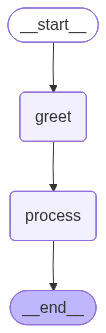

In [2]:

import sys
import pysqlite3
sys.modules["sqlite3"] = sys.modules.pop("pysqlite3")
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,NotRequired
# 在 Jupyter Notebook 中可视化
from IPython.core.display import Image

load_dotenv()

required_env_vars = ["OPENAI_API_KEY", "OPENAI_BASE_URL", "LLM_MODEL"]
missing_vars = [var for var in required_env_vars if not os.getenv(var)]

if missing_vars:
    raise ValueError(f"请检查 .env 文件！缺失以下配置: {', '.join(missing_vars)}")

class SimpleState(TypedDict):
    message: str
    processed: bool

def greet_node(state: SimpleState) -> dict:
    """欢迎节点：生成问候语"""
    print(f"[greet_node] 收到消息: {state['message']}")
    return {"message": f"你好！{state['message']}"}

def process_node(state: SimpleState) -> dict:
    """处理节点：标记为已处理"""
    print(f"[process_node] 处理消息: {state['message']}")
    return {"processed": True}


model = ChatOpenAI(model=os.getenv("LLM_MODEL","gpt-4o-mini"))

# Step 3: 构建图
builder = StateGraph(SimpleState)

# 添加节点
builder.add_node("greet", greet_node)
builder.add_node("process", process_node)

# 添加边
builder.add_edge(START, "greet")
builder.add_edge("greet", "process")
builder.add_edge("process", END)

# Step 4: 编译图
graph = builder.compile()

# Step 5: 运行
result = graph.invoke({"message": "世界","processed": False})

print(f"\n最终结果: {result}")

Image(graph.get_graph().draw_mermaid_png())

In [ ]:
Image(graph.get_graph().draw_mermaid_png())